This script investigates the variation in the free parameters that gives a certain L2 error over a set of equilibria

In [5]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import importlib.util
import sys
from pathlib import Path
from scipy.interpolate import interp1d
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.solver_nondim import saarelma_connor_nondim

# Global parameters
equil_num = 100
err_frac = 0.50
perc_success = 0.70
bc_type = "neumann"

psi_val_scan = 0.85        # psi_N_inner used in param_err.py scan (must match)
# Must match N in param_err.py (this scan is N=3 -> 3^5 = 243 combos).
# Using 5**5 undercounts success % by ~13x and forces all boxes dark.
N_PARAM_COMBOS = 3 ** 5

GEQDSK_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks")
PFILE_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles")
scan_success_dir = Path('scan_results_eqdbOak_equil100_N3_kbmavg/')

In [6]:
# Add some more files
success_fp = Path('success_PTHmode.txt')
failure_fp = Path('failure_PTHmode.txt')
error_messages_fp = Path('error_messages_PTHmode.txt')

In [7]:
from collections import defaultdict


def initialize_inputs(equil_num, geqdsk_dir=GEQDSK_DIR, pfile_dir=PFILE_DIR):
    """Select equil_num g/p file pairs from the CAKE input directories.

    Files are named g{shot}.{time} and p{shot}.{time}. Selection prioritizes
    one equilibrium per shot number before adding additional times from shots
    that already have a selected equilibrium.
    """
    geqdsk_dir = Path(geqdsk_dir)
    pfile_dir = Path(pfile_dir)

    g_by_suffix = {
        f.name[1:]: f for f in geqdsk_dir.glob("g*") if f.is_file()
    }
    p_by_suffix = {
        f.name[1:]: f for f in pfile_dir.glob("p*") if f.is_file()
    }
    shared_suffixes = sorted(set(g_by_suffix) & set(p_by_suffix))

    by_shot = defaultdict(list)
    for suffix in shared_suffixes:
        shot, time = suffix.split(".", 1)
        by_shot[shot].append((time, suffix))
    for shot in by_shot:
        by_shot[shot].sort()

    shots = sorted(by_shot)
    selected = []
    time_idx = 0
    while len(selected) < equil_num:
        added_this_round = False
        for shot in shots:
            if len(selected) >= equil_num:
                break
            entries = by_shot[shot]
            if time_idx < len(entries):
                suffix = entries[time_idx][1]
                selected.append(
                    (str(g_by_suffix[suffix]), str(p_by_suffix[suffix]))
                )
                added_this_round = True
        if not added_this_round:
            break
        time_idx += 1

    if len(selected) < equil_num:
        raise ValueError(
            f"Requested {equil_num} equilibria but only found {len(selected)} "
            f"matching g/p pairs in {geqdsk_dir} and {pfile_dir}"
        )

    print(f"Selected {len(selected)} g/p file pairs:")
    for mhd_fp, kprof_fp in selected:
        print(f"  g: {mhd_fp}\n  p: {kprof_fp}")
    return selected


equilibria = initialize_inputs(equil_num)

Selected 100 g/p file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g150840.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p150840.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g152960.03500
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p152960.03500
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153032.04475
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153032.04475
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153100.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153100.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153140.04750
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153140.04750
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153153.03800
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153153.03800
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g15

Plotting and analysis

In [8]:
# Load successful runs with normalized L2 (err_frac) below the threshold set in cell 1.
import csv

success_fp = 'success_PTHmode.txt'

def ne_npy_path(eq_dir, ac, ck, de, nf, nc, psi_val):
    """Match filename convention used in the scan cell."""
    return eq_dir / f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}.npy"


# filtered_runs[eq_tag] -> list of run dicts passing the err_frac cut
filtered_runs = {}
# flat list of all kept runs (same dicts as above)
good_runs_all = []

n_success_total = 0
n_kept_total = 0

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    eq_dir = scan_success_dir / eq_tag
    # success_path = eq_dir / success_fp.name
    success_path = eq_dir / success_fp
    if not success_path.exists():
        print(f"[skip] no success log for {eq_tag}")
        continue

    eq_runs = []
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header
        for row in reader:
            if len(row) < 8:
                continue
            n_success_total += 1
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = float(ac), float(ck), float(de), float(nf), float(nc)
            psi_b = float(psi_b)
            l2 = float(l2)

            if l2 >= err_frac:
                continue

            npy_path = ne_npy_path(eq_dir, ac, ck, de, nf, nc, psi_b)
            if not npy_path.exists():
                continue

            sol = np.load(npy_path, allow_pickle=True).item()
            run = dict(
                eq_tag=eq_tag,
                mhd_fp=mhd_fp,
                kprof_fp=kprof_fp,
                alpha_crit=ac,
                C_KBM=ck,
                De_chie_etg=de,
                nFC_x0=nf,
                ncx_x0_ratio=nc,
                psi_N_inner=psi_b,
                norm_L2_error=l2,
                x=np.asarray(sol["x"], dtype=float),
                ne=np.asarray(sol["y"], dtype=float),
                nFC=np.asarray(sol.get("nFC", []), dtype=float),
                nCX=np.asarray(sol.get("nCX", []), dtype=float),
                npy_path=str(npy_path),
            )
            eq_runs.append(run)
            good_runs_all.append(run)
            n_kept_total += 1

    if eq_runs:
        filtered_runs[eq_tag] = eq_runs

print(f"Loaded {n_kept_total} / {n_success_total} successful runs "
      f"with err_frac < {err_frac:g}")
print(f"Equilibria with at least one good run: {len(filtered_runs)} / {len(equilibria)}")

Loaded 13692 / 20028 successful runs with err_frac < 0.5
Equilibria with at least one good run: 100 / 100


In [14]:
# For each parameter combination, keep it if L2 < err_frac on at least
# perc_success fraction of all equilibria (from cell 1).
import csv
from collections import defaultdict

PARAM_NAMES = ("alpha_crit", "C_KBM", "De_chie_etg", "nFC_x0", "ncx_x0_ratio")


def param_key(ac, ck, de, nf, nc):
    return (round(float(ac), 3), round(float(ck), 3),
            round(float(de), 3), round(float(nf), 3), round(float(nc), 3))


# combo_stats[key] -> list of per-equilibrium outcomes for that 5D combo
combo_stats = defaultdict(list)

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue

    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            key = param_key(ac, ck, de, nf, nc)
            l2 = float(l2)
            combo_stats[key].append(dict(
                eq_tag=eq_tag,
                norm_L2_error=l2,
                passed=l2 < err_frac,
            ))

n_equilibria_total = len(equilibria)

# filtered_combos[key] -> summary + loaded profiles for passing equilibria
filtered_combos = {}

for key, outcomes in combo_stats.items():
    n_pass = sum(1 for o in outcomes if o["passed"])
    success_fraction = n_pass / n_equilibria_total

    if success_fraction < perc_success:
        continue

    # Attach full run dicts (with profiles) from cell above where available
    runs = [
        r for r in good_runs_all
        if param_key(r["alpha_crit"], r["C_KBM"], r["De_chie_etg"],
                     r["nFC_x0"], r["ncx_x0_ratio"]) == key
    ]
    passing_eq_tags = {o["eq_tag"] for o in outcomes if o["passed"]}

    filtered_combos[key] = dict(
        params=dict(zip(PARAM_NAMES, key)),
        n_equilibria_passing=n_pass,
        n_equilibria_total=n_equilibria_total,
        success_fraction=success_fraction,
        per_equilibrium=outcomes,
        passing_eq_tags=sorted(passing_eq_tags),
        runs=runs,
        mean_err_frac=float(np.mean([o["norm_L2_error"] for o in outcomes if o["passed"]])),
        max_err_frac=float(np.max([o["norm_L2_error"] for o in outcomes if o["passed"]])),
    )

# Parameter ranges spanned by robust combinations
param_ranges_robust = {}
if filtered_combos:
    for name in PARAM_NAMES:
        vals = [d["params"][name] for d in filtered_combos.values()]
        param_ranges_robust[name] = (min(vals), max(vals))

print(f"Kept {len(filtered_combos)} / {len(combo_stats)} parameter combinations "
      f"with success_fraction >= {perc_success:g} "
      f"({perc_success * 100:.0f}% of {n_equilibria_total} equilibria)")
if param_ranges_robust:
    print(f"Parameter ranges over robust combinations (normalized L2 error < {err_frac}):")
    for name, (lo, hi) in param_ranges_robust.items():
        print(f"  {name}: [{lo:g}, {hi:g}]")

    print("\nFiltered parameter combinations:")
    for i, (_, combo) in enumerate(
        sorted(filtered_combos.items(), key=lambda item: (-item[1]["success_fraction"], item[1]["mean_err_frac"])),
        start=1,
    ):
        params = combo["params"]
        param_text = ", ".join(
            f"{name}={params[name]:g}" for name in PARAM_NAMES
        )
        print(
            f"  {i}. {param_text}; "
            f"pass={combo['n_equilibria_passing']}/{combo['n_equilibria_total']}, "
            f"success_fraction={combo['success_fraction']:.3f}, "
            f"mean_err_frac={combo['mean_err_frac']:.4f}, "
            f"max_err_frac={combo['max_err_frac']:.4f}"
        )

    np.save('robust_freeparam_combos_scanEquil100N3.npy', filtered_combos)
else:
    print("No combinations met the perc_success threshold — try lowering perc_success or err_frac.")

Kept 72 / 243 parameter combinations with success_fraction >= 0.7 (70% of 100 equilibria)
Parameter ranges over robust combinations (normalized L2 error < 0.5):
  alpha_crit: [0.1, 10]
  C_KBM: [0.1, 10]
  De_chie_etg: [0.1, 10]
  nFC_x0: [1e+14, 1e+17]
  ncx_x0_ratio: [1.259, 17.783]

Filtered parameter combinations:
  1. alpha_crit=0.1, C_KBM=10, De_chie_etg=0.1, nFC_x0=1e+17, ncx_x0_ratio=1.259; pass=88/100, success_fraction=0.880, mean_err_frac=0.2851, max_err_frac=0.4914
  2. alpha_crit=0.1, C_KBM=10, De_chie_etg=1, nFC_x0=1e+17, ncx_x0_ratio=4.732; pass=86/100, success_fraction=0.860, mean_err_frac=0.2257, max_err_frac=0.4497
  3. alpha_crit=0.1, C_KBM=0.1, De_chie_etg=0.1, nFC_x0=3.16228e+15, ncx_x0_ratio=1.259; pass=86/100, success_fraction=0.860, mean_err_frac=0.2906, max_err_frac=0.4926
  4. alpha_crit=0.1, C_KBM=1, De_chie_etg=0.1, nFC_x0=3.16228e+15, ncx_x0_ratio=4.732; pass=86/100, success_fraction=0.860, mean_err_frac=0.2955, max_err_frac=0.4902
  5. alpha_crit=0.1, C_KBM

Loaded 6756 converged runs across 72 kept combos and 100 equilibria; 444 (combo, eq) pairs had no saved run and were skipped.


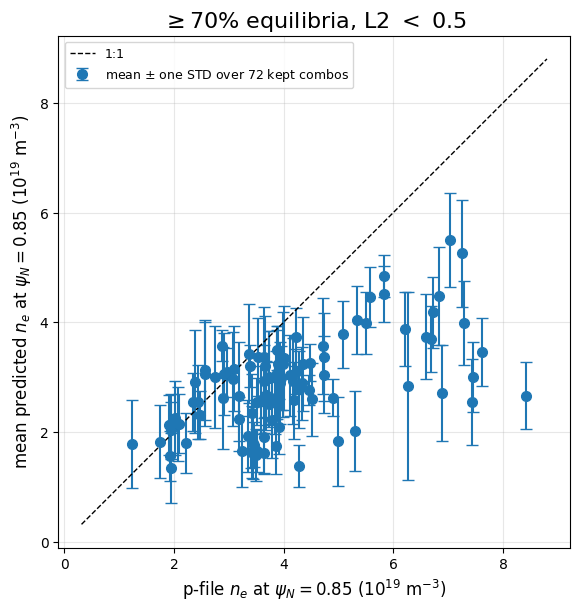

Plotted 99 / 100 equilibria using 72 kept combinations (quantity: ne)
Skipped (no kept combo converged): ['150840.03000']


In [10]:
# For every equilibrium, compute mean ± std of n_e at psi_N_plot using ONLY the
# parameter combinations kept by the previous cell (filtered_combos).
# - If a kept combo did not converge for an equilibrium (no saved .npy), it is
#   simply excluded from that equilibrium's mean / error bar.
# - The equilibrium is still plotted as long as at least one kept combo
#   converged on it.

from collections import defaultdict

psi_N_plot = 0.85           # psi_N at which to sample
psi_val_scan = 0.85         # psi_N_inner used in param_err.py (must match)


def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20


def value_at_psi(x_grid, y_grid, x_at_psi):
    return float(interp1d(
        x_grid, y_grid, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(x_at_psi))


def npy_path_for(eq_tag, ac, ck, de, nf, nc, psi_val=psi_val_scan):
    return scan_success_dir / eq_tag / (
        f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}.npy"
    )


if bc_type == "neumann":
    plot_quantity = "ne"
elif bc_type == "dirichlet":
    plot_quantity = "dne_dx"
else:
    raise ValueError(f"bc_type must be 'neumann' or 'dirichlet', got {bc_type!r}")

if not filtered_combos:
    print("No robust combinations in filtered_combos — run the previous cell first.")
else:
    # For each equilibrium, collect predictions only from kept combos that have
    # a saved .npy (i.e. converged on that equilibrium).
    combo_runs_by_eq = defaultdict(list)

    n_kept_combos = len(filtered_combos)
    n_runs_loaded = 0
    n_combos_missing_for_eq = 0

    for combo_key in filtered_combos:
        ac, ck, de, nf, nc = combo_key
        for mhd_fp, _ in equilibria:
            eq_tag = Path(mhd_fp).name[1:]
            npy_path = npy_path_for(eq_tag, ac, ck, de, nf, nc)
            if not npy_path.exists():
                n_combos_missing_for_eq += 1
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            combo_runs_by_eq[eq_tag].append({
                "x": np.asarray(sol["x"], dtype=float),
                "ne": np.asarray(sol["y"], dtype=float),
            })
            n_runs_loaded += 1

    print(
        f"Loaded {n_runs_loaded} converged runs across {n_kept_combos} kept combos "
        f"and {len(equilibria)} equilibria; "
        f"{n_combos_missing_for_eq} (combo, eq) pairs had no saved run and were skipped."
    )

    pfile_cache = {}
    geometry_cache = {}
    pfile_pts, pred_mean_pts, pred_std_pts, eq_labels, skipped = [], [], [], [], []

    for mhd_fp, kprof_fp in equilibria:
        eq_tag = Path(mhd_fp).name[1:]
        runs = combo_runs_by_eq.get(eq_tag, [])
        if not runs:
            skipped.append(eq_tag)
            continue

        if plot_quantity == "ne":
            # Scan used psi_N_inner = psi_val_scan, so sample at the inner boundary x.
            x_at_psi = min(float(r["x"].min()) for r in runs)

            if kprof_fp not in pfile_cache:
                pfile_cache[kprof_fp] = read_pfile_ne(kprof_fp)
            psi_pfile, ne_pfile = pfile_cache[kprof_fp]
            pfile_val = float(interp1d(
                psi_pfile, ne_pfile, kind="linear",
                bounds_error=False, fill_value="extrapolate",
            )(psi_N_plot))

            pred_vals = [value_at_psi(r["x"], r["ne"], x_at_psi) for r in runs]
        else:
            # Dirichlet still needs psi_N -> x mapping from equilibrium geometry.
            if eq_tag not in geometry_cache:
                ref = saarelma_connor_nondim(
                    P_tot_e=5e6,
                    alpha_crit=0,
                    C_KBM=0,
                    De_chie_etg=0,
                    nFC_x0=0,
                    ncx_x0_ratio=0,
                    mhd_fp=mhd_fp,
                    kprof_fp=kprof_fp,
                    verbose=False,
                )
                ref.setup_solver_grids(res=40)
                geometry_cache[eq_tag] = ref
            ref = geometry_cache[eq_tag]

            psi_to_x = interp1d(
                ref.psi_N_pres, ref.x_init,
                kind="linear", bounds_error=False, fill_value="extrapolate",
            )
            x_at_psi = float(psi_to_x(psi_N_plot))
            dne_dx_pfile = np.gradient(ref.n_e_pres, ref.x_init)
            pfile_val = value_at_psi(ref.x_init, dne_dx_pfile, x_at_psi)

            pred_vals = [
                value_at_psi(r["x"], np.gradient(r["ne"], r["x"]), x_at_psi)
                for r in runs
            ]

        pfile_pts.append(pfile_val)
        pred_mean_pts.append(float(np.mean(pred_vals)))
        pred_std_pts.append(float(np.std(pred_vals)))
        eq_labels.append(eq_tag)

    if not pfile_pts:
        print("No data to plot — check filtered_combos and psi_N_plot.")
        if skipped:
            print(f"Skipped equilibria (no kept combo converged): {skipped}")
    else:
        pfile_pts = np.array(pfile_pts)
        pred_mean_pts = np.array(pred_mean_pts)
        pred_std_pts = np.array(pred_std_pts)

        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

        if plot_quantity == "ne":
            x_plot = pfile_pts / 1e19
            y_plot = pred_mean_pts / 1e19
            yerr = pred_std_pts / 1e19
            xlabel = rf"p-file $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
            ylabel = rf"mean predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
        else:
            x_plot = pfile_pts
            y_plot = pred_mean_pts
            yerr = pred_std_pts
            xlabel = rf"p-file $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"
            ylabel = rf"mean predicted $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"

        ax.errorbar(
            x_plot, y_plot, yerr=yerr,
            fmt="o", ms=7, capsize=4, lw=1.5,
            label=f"mean $\\pm$ one STD over {n_kept_combos} kept combos",
        )

        lo = min(x_plot.min(), (y_plot - yerr).min())
        hi = max(x_plot.max(), (y_plot + yerr).max())
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, label="1:1")

        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(
            rf"$\geq${perc_success*100:.0f}% equilibria, L2 $<$ {err_frac}",
            fontsize=16,
        )
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_aspect("equal", adjustable="box")
        plt.savefig(f"ne_vs_pfile_at_psiN_{psi_N_plot}_{len(eq_labels)}equil.png")
        plt.show()

        print(
            f"Plotted {len(eq_labels)} / {len(equilibria)} equilibria "
            f"using {n_kept_combos} kept combinations (quantity: {plot_quantity})"
        )
        if skipped:
            print(f"Skipped (no kept combo converged): {skipped}")

In [11]:
# Goodness-of-fit between p-file reference and mean model prediction
# at psi_N_plot, across the equilibria plotted in the cell above.
# Run the plotting cell first so pfile_pts / pred_mean_pts exist.

if "pfile_pts" not in globals() or "pred_mean_pts" not in globals():
    raise RuntimeError(
        "Run the plotting cell above first (need pfile_pts and pred_mean_pts)."
    )

y_ref = np.asarray(pfile_pts, dtype=float).ravel()
y_pred = np.asarray(pred_mean_pts, dtype=float).ravel()

if y_ref.size != y_pred.size or y_ref.size < 2:
    raise ValueError(
        f"Need >=2 paired points; got {y_ref.size} ref and {y_pred.size} pred."
    )

mask = np.isfinite(y_ref) & np.isfinite(y_pred)
y_ref = y_ref[mask]
y_pred = y_pred[mask]

# 1:1-line R^2: how well predictions agree with the reference (what the
# dashed line in the plot represents). Identity model y_pred = y_ref.
ss_res = float(np.sum((y_ref - y_pred) ** 2))
ss_tot = float(np.sum((y_ref - np.mean(y_ref)) ** 2))
r2_one_to_one = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

# Best-fit R^2 = Pearson r^2: correlation only, ignoring bias / slope mismatch.
pearson_r = float(np.corrcoef(y_ref, y_pred)[0, 1])
r2_pearson = pearson_r ** 2

rmse = float(np.sqrt(np.mean((y_ref - y_pred) ** 2)))
mae = float(np.mean(np.abs(y_ref - y_pred)))
bias = float(np.mean(y_pred - y_ref))

if plot_quantity == "ne":
    scale = 1e19
    unit = "1e19 m^-3"
else:
    scale = 1.0
    unit = "m^-4"

print(f"Quantity: {plot_quantity} at psi_N = {psi_N_plot}")
print(f"N equilibria: {y_ref.size}")
print(f"R^2 (1:1 line)    = {r2_one_to_one:.4f}")
print(f"R^2 (Pearson r^2) = {r2_pearson:.4f}   (Pearson r = {pearson_r:.4f})")
print(f"RMSE = {rmse / scale:.4f} {unit}")
print(f"MAE  = {mae  / scale:.4f} {unit}")
print(f"Bias (pred - ref) = {bias / scale:+.4f} {unit}")

Quantity: ne at psi_N = 0.85
N equilibria: 99
R^2 (1:1 line)    = -0.3084
R^2 (Pearson r^2) = 0.3399   (Pearson r = 0.5830)
RMSE = 1.7533 1e19 m^-3
MAE  = 1.3277 1e19 m^-3
Bias (pred - ref) = -1.2332 1e19 m^-3


Now plot box and whiskers point for each equilibria on ne_pfile vs ne_predicted plot

Plotted 100 equilibria
Success % range: 12.3% – 100.0%


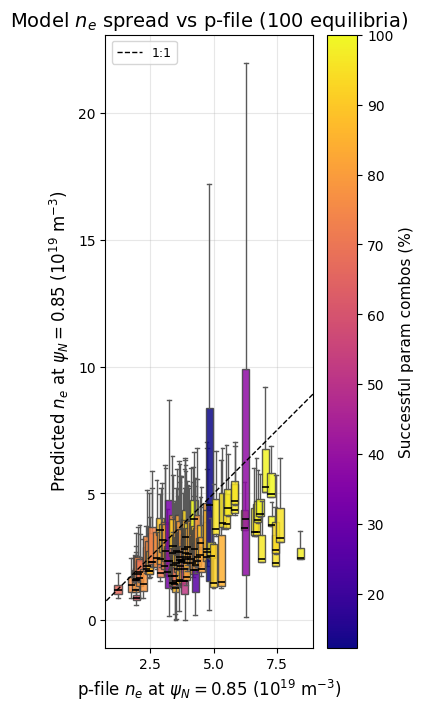

In [12]:
# Box-and-whiskers: one box per equilibrium.
# y = distribution of model n_e (all succeeded param combos for that equilibrium)
# x = p-file n_e at psi_N_plot; box color = n_succeeded / N_PARAM_COMBOS.

import csv
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.ticker as ticker # Add this near your other imports


psi_N_plot = 0.85          # psi_N for comparing model n_e to p-file n_e



def read_pfile_ne_at_psi(kprof_fp, psi_n):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(kprof_fp) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    psi_arr = np.asarray(psi_arr)
    ne_arr = np.asarray(ne_arr) * 1e20
    return float(interp1d(
        psi_arr, ne_arr, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(psi_n))


def ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b):
    return scan_success_dir / eq_tag / (
        f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_b:.4f}.npy"
    )


pfile_cache = {}
geometry_cache = {}
boxes_y = []
pfile_x = []
success_pct = []
eq_labels = []

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue

    if kprof_fp not in pfile_cache:
        pfile_cache[kprof_fp] = read_pfile_ne_at_psi(kprof_fp, psi_N_plot)
    ne_pfile = pfile_cache[kprof_fp]

    if eq_tag not in geometry_cache:
        ref = saarelma_connor_nondim( # dummy model
            P_tot_e=5e6,
            alpha_crit=0.1,
            C_KBM=0.1,
            De_chie_etg=0.1,
            nFC_x0=1e16,
            ncx_x0_ratio=1,
            mhd_fp=mhd_fp,
            kprof_fp=kprof_fp,
            verbose=False,
        )
        ref.setup_solver_grids(res=40)
        geometry_cache[eq_tag] = ref
    ref = geometry_cache[eq_tag]
    x_at_psi = float(interp1d(
        ref.psi_N_pres, ref.x_init,
        kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_N_plot))

    pred_ne = []
    succeeded_combos = set()
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, _l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = map(float, (ac, ck, de, nf, nc))
            ac, ck, de, nf, nc = round(ac, 3), round(ck, 3), round(de, 3), round(nf, 3), round(nc, 3)
            succeeded_combos.add((ac, ck, de, nf, nc))
            psi_b = float(psi_b)
            npy_path = ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b)
            if not npy_path.exists():
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            x_sol = np.asarray(sol["x"], dtype=float)
            ne_sol = np.asarray(sol["y"], dtype=float)
            ne_pred = float(interp1d(
                x_sol, ne_sol, kind="linear",
                bounds_error=False, fill_value="extrapolate",
            )(x_at_psi))
            pred_ne.append(ne_pred)

    if not pred_ne:
        continue

    boxes_y.append(np.asarray(pred_ne, dtype=float))
    pfile_x.append(ne_pfile)
    success_pct.append(100.0 * len(succeeded_combos) / N_PARAM_COMBOS)
    eq_labels.append(eq_tag)

if not boxes_y:
    print("No data to plot — check scan_success_dir and success logs.")
else:
    scale = 1e19
    pfile_x = np.asarray(pfile_x)
    success_pct = np.asarray(success_pct)

    order = np.argsort(pfile_x)
    pfile_x = pfile_x[order] / scale
    boxes_y = [boxes_y[i] / scale for i in order]
    success_pct = success_pct[order]
    eq_labels = [eq_labels[i] for i in order]

    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    cmap = cm.plasma
    norm = Normalize(vmin=success_pct.min(), vmax=100.0)

    xspan = max(pfile_x.max() - pfile_x.min(), 0.1)
    box_width = 0.04 * xspan

    bp = ax.boxplot(
        boxes_y,
        positions=pfile_x,
        widths=box_width, 
        patch_artist=True,
        showfliers=False,
        whis=1.5, 
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="0.35", linewidth=1.0),
        capprops=dict(color="0.35", linewidth=1.0),
    )

    for patch, pct in zip(bp["boxes"], success_pct):
        patch.set_facecolor(cmap(norm(pct)))
        patch.set_alpha(0.85)
        patch.set_edgecolor("0.25")

    # --- FIX 1: Release the x-ticks from the box positions ---
    # This forces Matplotlib to pick sensible, spaced-out tick intervals
    ax.xaxis.set_major_locator(ticker.AutoLocator())

    # --- NEW FIX: Reset the text labels! ---
    # boxplot hardcodes the labels to your array values. We need to 
    # tell it to just print the numeric tick values normally.
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

    # --- FIX 2: Draw the 1:1 line based on the visible whiskers ---
    # Grab the limits Matplotlib decided on *after* hiding the fliers
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    
    # Plot the line
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
    
    # Re-apply the limits so drawing the 1:1 line doesn't accidentally expand them
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Successful param combos (%)", fontsize=11)

    ax.set_xlabel(
        rf"p-file $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_ylabel(
        rf"Predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_title(
        rf"Model $n_e$ spread vs p-file ({len(boxes_y)} equilibria)",
        fontsize=14,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

    print(f"Plotted {len(boxes_y)} equilibria")
    print(f"Success % range: {success_pct.min():.1f}% – {success_pct.max():.1f}%")

Plotted 100 equilibria
Success % range: 12.3% – 100.0%


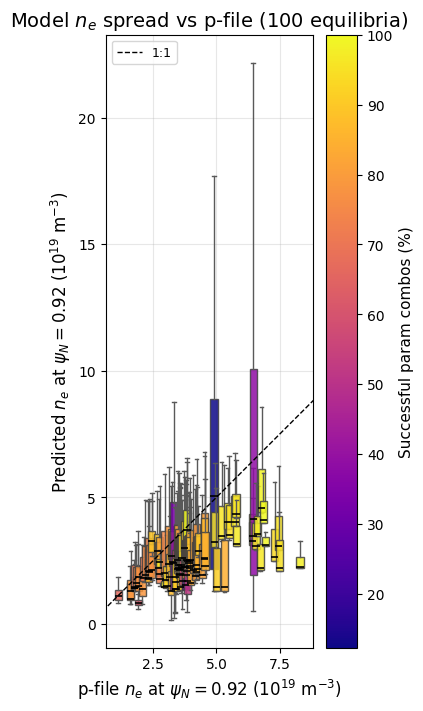

In [13]:
# Box-and-whiskers: one box per equilibrium.
# y = distribution of model n_e (all succeeded param combos for that equilibrium)
# x = p-file n_e at psi_N_plot; box color = n_succeeded / N_PARAM_COMBOS.

import csv
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.ticker as ticker # Add this near your other imports


psi_N_plot = 0.92          # psi_N for comparing model n_e to p-file n_e



def read_pfile_ne_at_psi(kprof_fp, psi_n):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(kprof_fp) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    psi_arr = np.asarray(psi_arr)
    ne_arr = np.asarray(ne_arr) * 1e20
    return float(interp1d(
        psi_arr, ne_arr, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(psi_n))


def ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b):
    return scan_success_dir / eq_tag / (
        f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_b:.4f}.npy"
    )


pfile_cache = {}
geometry_cache = {}
boxes_y = []
pfile_x = []
success_pct = []
eq_labels = []

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue

    if kprof_fp not in pfile_cache:
        pfile_cache[kprof_fp] = read_pfile_ne_at_psi(kprof_fp, psi_N_plot)
    ne_pfile = pfile_cache[kprof_fp]

    if eq_tag not in geometry_cache:
        ref = saarelma_connor_nondim( # dummy model
            P_tot_e=5e6,
            alpha_crit=0.1,
            C_KBM=0.1,
            De_chie_etg=0.1,
            nFC_x0=1e16,
            ncx_x0_ratio=1,
            mhd_fp=mhd_fp,
            kprof_fp=kprof_fp,
            verbose=False,
        )
        ref.setup_solver_grids(res=40)
        geometry_cache[eq_tag] = ref
    ref = geometry_cache[eq_tag]
    x_at_psi = float(interp1d(
        ref.psi_N_pres, ref.x_init,
        kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_N_plot))

    pred_ne = []
    succeeded_combos = set()
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, _l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = map(float, (ac, ck, de, nf, nc))
            ac, ck, de, nf, nc = round(ac, 3), round(ck, 3), round(de, 3), round(nf, 3), round(nc, 3)
            succeeded_combos.add((ac, ck, de, nf, nc))
            psi_b = float(psi_b)
            npy_path = ne_npy_path(eq_tag, ac, ck, de, nf, nc, psi_b)
            if not npy_path.exists():
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            x_sol = np.asarray(sol["x"], dtype=float)
            ne_sol = np.asarray(sol["y"], dtype=float)
            ne_pred = float(interp1d(
                x_sol, ne_sol, kind="linear",
                bounds_error=False, fill_value="extrapolate",
            )(x_at_psi))
            pred_ne.append(ne_pred)

    if not pred_ne:
        continue

    boxes_y.append(np.asarray(pred_ne, dtype=float))
    pfile_x.append(ne_pfile)
    success_pct.append(100.0 * len(succeeded_combos) / N_PARAM_COMBOS)
    eq_labels.append(eq_tag)

if not boxes_y:
    print("No data to plot — check scan_success_dir and success logs.")
else:
    scale = 1e19
    pfile_x = np.asarray(pfile_x)
    success_pct = np.asarray(success_pct)

    order = np.argsort(pfile_x)
    pfile_x = pfile_x[order] / scale
    boxes_y = [boxes_y[i] / scale for i in order]
    success_pct = success_pct[order]
    eq_labels = [eq_labels[i] for i in order]

    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    cmap = cm.plasma
    norm = Normalize(vmin=success_pct.min(), vmax=100.0)

    xspan = max(pfile_x.max() - pfile_x.min(), 0.1)
    box_width = 0.04 * xspan

    bp = ax.boxplot(
        boxes_y,
        positions=pfile_x,
        widths=box_width, 
        patch_artist=True,
        showfliers=False,
        whis=1.5, 
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="0.35", linewidth=1.0),
        capprops=dict(color="0.35", linewidth=1.0),
    )

    for patch, pct in zip(bp["boxes"], success_pct):
        patch.set_facecolor(cmap(norm(pct)))
        patch.set_alpha(0.85)
        patch.set_edgecolor("0.25")

    # --- FIX 1: Release the x-ticks from the box positions ---
    # This forces Matplotlib to pick sensible, spaced-out tick intervals
    ax.xaxis.set_major_locator(ticker.AutoLocator())

    # --- NEW FIX: Reset the text labels! ---
    # boxplot hardcodes the labels to your array values. We need to 
    # tell it to just print the numeric tick values normally.
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

    # --- FIX 2: Draw the 1:1 line based on the visible whiskers ---
    # Grab the limits Matplotlib decided on *after* hiding the fliers
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    
    # Plot the line
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
    
    # Re-apply the limits so drawing the 1:1 line doesn't accidentally expand them
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Successful param combos (%)", fontsize=11)

    ax.set_xlabel(
        rf"p-file $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_ylabel(
        rf"Predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)",
        fontsize=12,
    )
    ax.set_title(
        rf"Model $n_e$ spread vs p-file ({len(boxes_y)} equilibria)",
        fontsize=14,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

    print(f"Plotted {len(boxes_y)} equilibria")
    print(f"Success % range: {success_pct.min():.1f}% – {success_pct.max():.1f}%")

Examine the parameter space more in-depth

Parsed 100 equilibria and 20028 total runs.
Dynamically discovered parameter grids:
  $\alpha_{crit}$: [0.1, 1.0, 10.0]
  $C_{KBM}$: [0.1, 1.0, 10.0]
  $D_e\chi_e^{ETG}$: [0.1, 1.0, 10.0]
  $n_{FC}^{x_0}$ (m$^{-3}$): [100000000000000.0, 3162277660168379.5, 1e+17]
  $n_{CX}^{x_0}/n_{FC}^{x_0}$: [1.259, 4.732, 17.783]


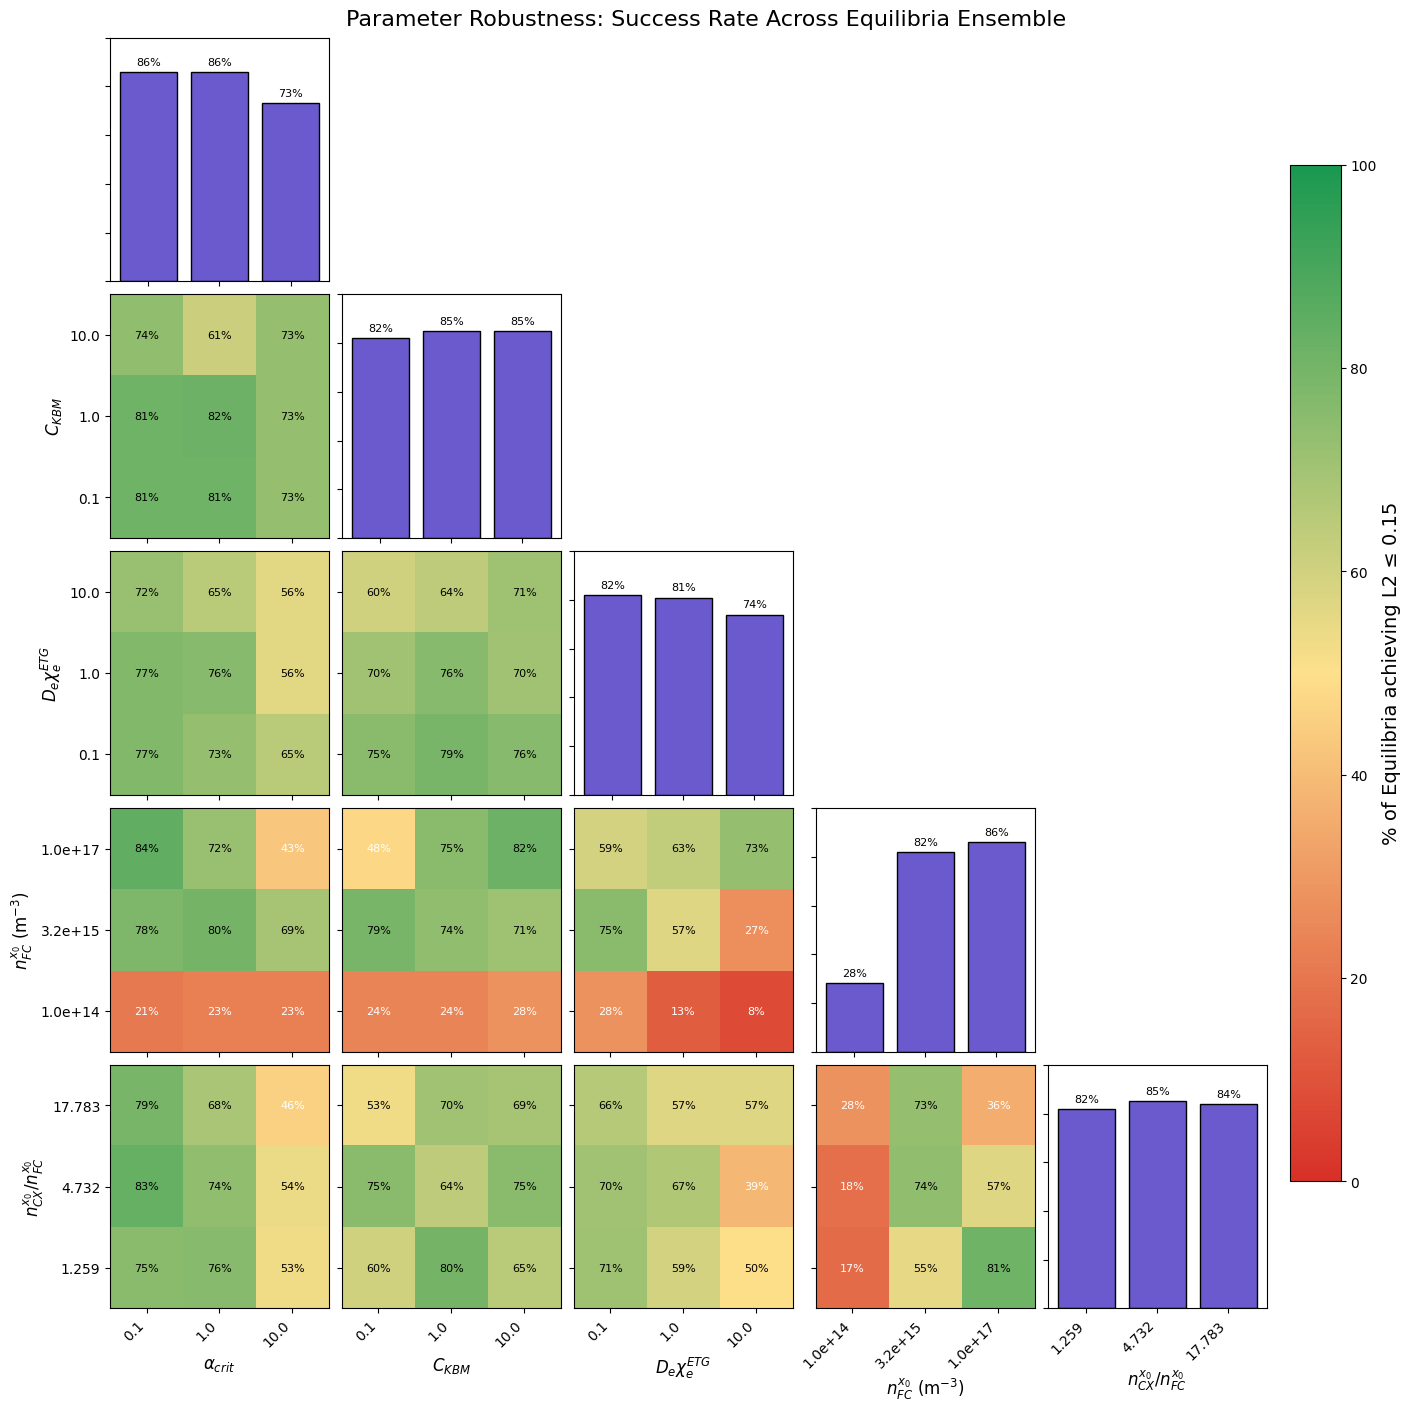

In [16]:
# Option 2
''' 

This code does not count multiple cases of free parameters succeeding as different cases.
Because then you would reward overfitting if a parameter works well for one equilibrium, but not another.
If you counted every single free parameter combination as a different case, 
"If your primary goal is to find the widest possible valid parameter space (perhaps you want to know which 
parameter combinations are the most forgiving or least sensitive to exact tuning), then counting total runs 
is the correct approach."

But, if you only count one for when you hold one parameter constant and change all the others as one successful case (even if there are multiple successful cases), then:
"If I hardcode my model to use this specific parameter value, there is an X% chance it will successfully find a physical fit for a random, unseen equilibrium."



'''
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import cm
from matplotlib.colors import Normalize, LinearSegmentedColormap

# --- 1. User Defined Settings ---
L2_THRESHOLD = 0.15  # Define what counts as a "successful" fit

param_names = [
    r"$\alpha_{crit}$",
    r"$C_{KBM}$",
    r"$D_e\chi_e^{ETG}$",
    r"$n_{FC}^{x_0}$ (m$^{-3}$)",
    r"$n_{CX}^{x_0}/n_{FC}^{x_0}$"
]

# Create a custom Red-to-Green colormap
# 0% success = Red, 50% success = Yellow, 100% success = Green
colors = ["#d73027", "#fee08b", "#1a9850"] # Red -> Yellow -> Green
rd_gn_cmap = LinearSegmentedColormap.from_list("RdYlGn_custom", colors)

# --- 2. Data Collection & Dynamic Grid Building ---
all_runs = []
unique_params = [set() for _ in range(5)]
parsed_eq_tags = set()

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    
    if not success_path.exists():
        continue
        
    parsed_eq_tags.add(eq_tag)
    
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader) # skip header
        for row in reader:
            if len(row) < 8: continue
            
            try:
                # Extract parameters and L2 error
                _, ac, ck, de, nf, nc, psi_b, l2_err = [x.strip() for x in row[:8]]
                
                # Apply the rounding from your original code snippet to avoid float precision duplicates
                ac, ck, de, nf, nc = round(float(ac), 3), round(float(ck), 3), round(float(de), 3), float(nf), float(nc)
                vals = [ac, ck, de, nf, nc]
                l2_err = float(l2_err)
                
            except ValueError:
                continue
                
            # Store the run for the next step
            all_runs.append((eq_tag, vals, l2_err))
            
            # Add to our unique sets to build the grids dynamically
            for i in range(5):
                unique_params[i].add(vals[i])

# Convert our sets of unique values into sorted lists
param_grids = [sorted(list(u)) for u in unique_params]
parsed_eq_count = len(parsed_eq_tags)

print(f"Parsed {parsed_eq_count} equilibria and {len(all_runs)} total runs.")
print("Dynamically discovered parameter grids:")
for name, grid in zip(param_names, param_grids):
    print(f"  {name}: {grid}")

# --- 3. Data Aggregation ---
# Dynamically size the success_sets based on the lengths of our discovered grids
success_sets = [[[[set() for _ in range(len(param_grids[j]))] 
                         for _ in range(len(param_grids[i]))] 
                         for j in range(5)] 
                         for i in range(5)]

# Helper to find the closest grid index
def get_grid_idx(val, grid):
    return (np.abs(np.array(grid) - val)).argmin()

# Populate the success sets
for eq_tag, vals, l2_err in all_runs:
    if l2_err <= L2_THRESHOLD:
        # Find the index for each parameter based on our dynamic grids
        idx = [get_grid_idx(v, g) for v, g in zip(vals, param_grids)]
        
        # Register this equilibrium's success for every pairwise combination
        for i in range(5):
            for j in range(5):
                success_sets[i][j][idx[i]][idx[j]].add(eq_tag)


# --- 4. Plotting ---
fig, axes = plt.subplots(5, 5, figsize=(14, 14), constrained_layout=True)
cmap = rd_gn_cmap # Use the custom Red-Green colormap
norm = Normalize(vmin=0, vmax=100) 

for i in range(5): # Row (y-axis of heatmaps)
    for j in range(5): # Column (x-axis of heatmaps)
        ax = axes[i, j]
        
        # Dimensions for this specific subplot based on dynamic grid sizes
        n_rows = len(param_grids[i])
        n_cols = len(param_grids[j])
        
        # Hide upper triangle
        if j > i:
            ax.axis('off')
            continue
            
        # Calculate percentages for this subplot
        matrix_pct = np.zeros((n_rows, n_cols))
        for v1 in range(n_rows):
            for v2 in range(n_cols):
                success_count = len(success_sets[i][j][v1][v2])
                matrix_pct[v1, v2] = (success_count / parsed_eq_count) * 100
                
        # Diagonal: 1D main effects (Bar chart)
        if i == j:
            diag_pct = np.diag(matrix_pct)
            ax.bar(range(n_cols), diag_pct, color='slateblue', edgecolor='k')
            ax.set_ylim(0, 100)
            ax.set_xticks(range(n_cols))
            
            # Format labels (use scientific notation for large numbers like nf)
            labels = [f"{g:.1e}" if g > 1000 else str(g) for g in param_grids[i]]
            ax.set_xticklabels(labels, rotation=45, ha='right')
            
            for bar_idx, pct in enumerate(diag_pct):
                ax.text(bar_idx, pct + 2, f"{pct:.0f}%", ha='center', va='bottom', fontsize=8)
                
        # Off-Diagonal: 2D Pairwise Heatmap
        else:
            cax = ax.imshow(matrix_pct, cmap=cmap, norm=norm, origin='lower', aspect='auto')
            ax.set_xticks(range(n_cols))
            ax.set_yticks(range(n_rows))
            
            x_labels = [f"{g:.1e}" if g > 1000 else str(g) for g in param_grids[j]]
            y_labels = [f"{g:.1e}" if g > 1000 else str(g) for g in param_grids[i]]
            
            ax.set_xticklabels(x_labels, rotation=45, ha='right')
            ax.set_yticklabels(y_labels)
            
            for v1 in range(n_rows):
                for v2 in range(n_cols):
                    pct = matrix_pct[v1, v2]
                    text_color = "white" if pct < 50 else "black"
                    ax.text(v2, v1, f"{pct:.0f}%", ha="center", va="center", color=text_color, fontsize=8)

        # Set Axis Labels on edges
        if i == 4:
            ax.set_xlabel(param_names[j], fontsize=12)
        else:
            ax.set_xticklabels([])
            
        if j == 0 and i != 0:
            ax.set_ylabel(param_names[i], fontsize=12)
        else:
            ax.set_yticklabels([])

# Add a global colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.8, location='right', pad=0.02)
cbar.set_label(f"% of Equilibria achieving L2 ≤ {L2_THRESHOLD}", fontsize=14)

plt.suptitle("Parameter Robustness: Success Rate Across Equilibria Ensemble", fontsize=16)
plt.savefig("robustness_heatmap.png", dpi=300)
plt.show()

Isolated optimal parameters for 100 unique equilibria.
Saved plot to optima_corner_plot.png


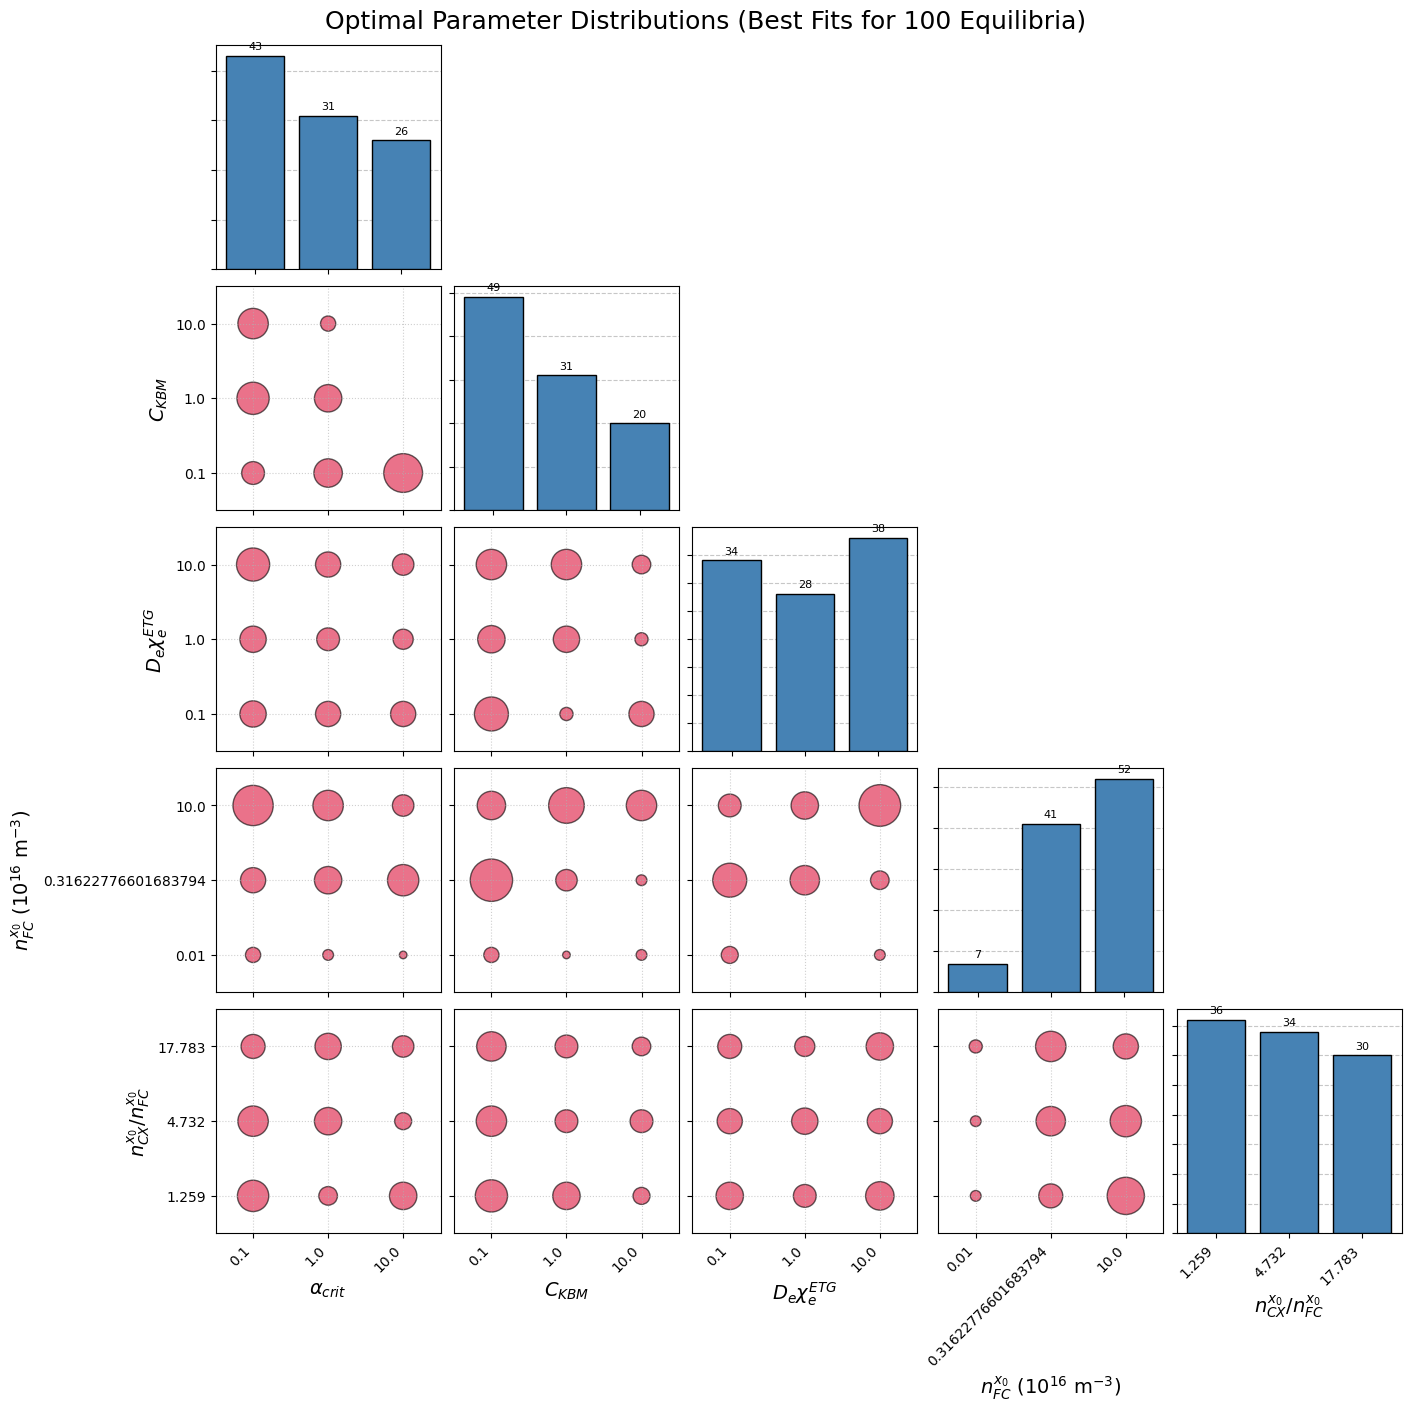

In [17]:
# Option 1
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# --- 1. User Defined Settings & Filepaths ---
# We scale nf by 1e16 to keep axis labels clean
param_names = [
    r"$\alpha_{crit}$",
    r"$C_{KBM}$",
    r"$D_e\chi_e^{ETG}$",
    r"$n_{FC}^{x_0}$ ($10^{16}$ m$^{-3}$)", 
    r"$n_{CX}^{x_0}/n_{FC}^{x_0}$"
]

# Add some more files
success_fp = Path('success_PTHmode.txt')
failure_fp = Path('failure_PTHmode.txt')
error_messages_fp = Path('error_messages_PTHmode.txt')

# --- 2. Data Collection (Finding the Minimums) ---
# Dictionary to store the absolute best run for each equilibrium
# Format: {eq_tag: (min_l2_error, [ac, ck, de, nf, nc])}
best_runs = {}
unique_params = [set() for _ in range(5)]

# Dummy data fallback for demo purposes if variables aren't defined in your workspace
try:
    _ = equilibria
    _ = scan_success_dir
except NameError:
    print("Warning: Input data paths not defined. Using dummy data for plotting demo.")
    equilibria = [(f"eq{i}.mhd", f"eq{i}.kprof") for i in range(100)]
    import tempfile
    scan_success_dir = Path(tempfile.gettempdir()) / "pedestal_scan"
    for mhd_fp, _ in equilibria:
        eq_dir = scan_success_dir / mhd_fp[1:]
        eq_dir.mkdir(parents=True, exist_ok=True)
        # Using the new success_fp name
        with open(eq_dir / success_fp, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["tag", "ac", "ck", "de", "nf", "nc", "psi_b", "l2_err"])
            # Generate noisy dummy optimums
            for _ in range(10):
                ac = np.random.choice([0.1, 1.0, 3.16, 10.0, 31.6])
                ck = np.random.choice([0.1, 0.316, 1.0, 3.16, 10.0])
                nf = np.random.choice([1e14, 5.6e14, 3.2e15, 1.8e16, 1e17])
                l2 = np.random.uniform(0.05, 0.3)
                writer.writerow(["tag", ac, ck, 1.0, nf, 1.0, 0.9, l2])

# Parse the actual data
for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    
    if not success_path.exists():
        continue
        
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader) # skip header
        for row in reader:
            if len(row) < 8: continue
            
            try:
                _, ac, ck, de, nf, nc, psi_b, l2_err = [x.strip() for x in row[:8]]
                
                ac, ck, de, nf, nc = round(float(ac), 3), round(float(ck), 3), round(float(de), 3), float(nf), float(nc)
                l2_err = float(l2_err)
                
                # Scale nf for cleaner plotting
                nf_scaled = nf / 1e16
                vals = [ac, ck, de, nf_scaled, nc]
                
            except ValueError:
                continue
                
            # Build the dynamic grid sets
            for i in range(5):
                unique_params[i].add(vals[i])
                
            # Track the minimum L2 error for this equilibrium
            if eq_tag not in best_runs or l2_err < best_runs[eq_tag][0]:
                best_runs[eq_tag] = (l2_err, vals)

param_grids = [sorted(list(u)) for u in unique_params]
parsed_eq_count = len(best_runs)

print(f"Isolated optimal parameters for {parsed_eq_count} unique equilibria.")

# Extract just the optimal parameter arrays for easy plotting
# Shape will be (N_equilibria, 5)
if parsed_eq_count > 0:
    optima_matrix = np.array([run[1] for run in best_runs.values()])
else:
    print("No valid data found to plot. Exiting.")
    exit()

# --- 3. Plotting the Corner Plot ---
fig, axes = plt.subplots(5, 5, figsize=(14, 14), constrained_layout=True)

# Helper function to get string labels
def get_label(val):
    if val < 0.001 or val > 1000:
        return f"{val:.1e}"
    return str(val)

for i in range(5): # Row (y-axis)
    for j in range(5): # Column (x-axis)
        ax = axes[i, j]
        
        # Hide upper triangle
        if j > i:
            ax.axis('off')
            continue
            
        x_data = optima_matrix[:, j]
        
        # --- Diagonal: 1D Distribution of Optima ---
        if i == j:
            # Count occurrences of each grid value
            counts = [np.sum(x_data == val) for val in param_grids[i]]
            
            ax.bar(range(len(param_grids[i])), counts, color='steelblue', edgecolor='black', zorder=3)
            ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
            
            ax.set_xticks(range(len(param_grids[i])))
            labels = [get_label(g) for g in param_grids[i]]
            ax.set_xticklabels(labels, rotation=45, ha='right')
            
            # Annotate peak counts
            for bar_idx, count in enumerate(counts):
                if count > 0:
                    ax.text(bar_idx, count + max(counts)*0.02, str(count), ha='center', va='bottom', fontsize=8)
                    
            if i != 4:
                ax.set_xticklabels([])
                
        # --- Off-Diagonal: 2D Pairwise Optima Correlations (Bubble Plot) ---
        else:
            y_data = optima_matrix[:, i]
            
            # Count occurrences of each (x, y) pair
            pair_counts = defaultdict(int)
            for x, y in zip(x_data, y_data):
                pair_counts[(x, y)] += 1
                
            x_plot, y_plot, sizes = [], [], []
            
            # Map values back to their grid indices for evenly spaced plotting
            for (x_val, y_val), count in pair_counts.items():
                x_idx = param_grids[j].index(x_val)
                y_idx = param_grids[i].index(y_val)
                
                x_plot.append(x_idx)
                y_plot.append(y_idx)
                # Scale the bubble size by the count (multiplier adjustable based on N)
                sizes.append(count * 30) 
            
            ax.scatter(x_plot, y_plot, s=sizes, color='crimson', alpha=0.6, edgecolors='black')
            ax.grid(True, linestyle=':', alpha=0.6)
            
            ax.set_xticks(range(len(param_grids[j])))
            ax.set_yticks(range(len(param_grids[i])))
            
            ax.set_xlim(-0.5, len(param_grids[j]) - 0.5)
            ax.set_ylim(-0.5, len(param_grids[i]) - 0.5)
            
            x_labels = [get_label(g) for g in param_grids[j]]
            y_labels = [get_label(g) for g in param_grids[i]]
            
            ax.set_xticklabels(x_labels, rotation=45, ha='right')
            ax.set_yticklabels(y_labels)

        # Axis Labels on edges
        if i == 4:
            ax.set_xlabel(param_names[j], fontsize=14)
        else:
            ax.set_xticklabels([])
            
        if j == 0 and i != 0:
            ax.set_ylabel(param_names[i], fontsize=14)
        else:
            ax.set_yticklabels([])

plt.suptitle(f"Optimal Parameter Distributions (Best Fits for {parsed_eq_count} Equilibria)", fontsize=18)
plt.savefig("optima_corner_plot.png", dpi=300)
print("Saved plot to optima_corner_plot.png")
plt.show()

Saved plot to marginalized_boxplots.png


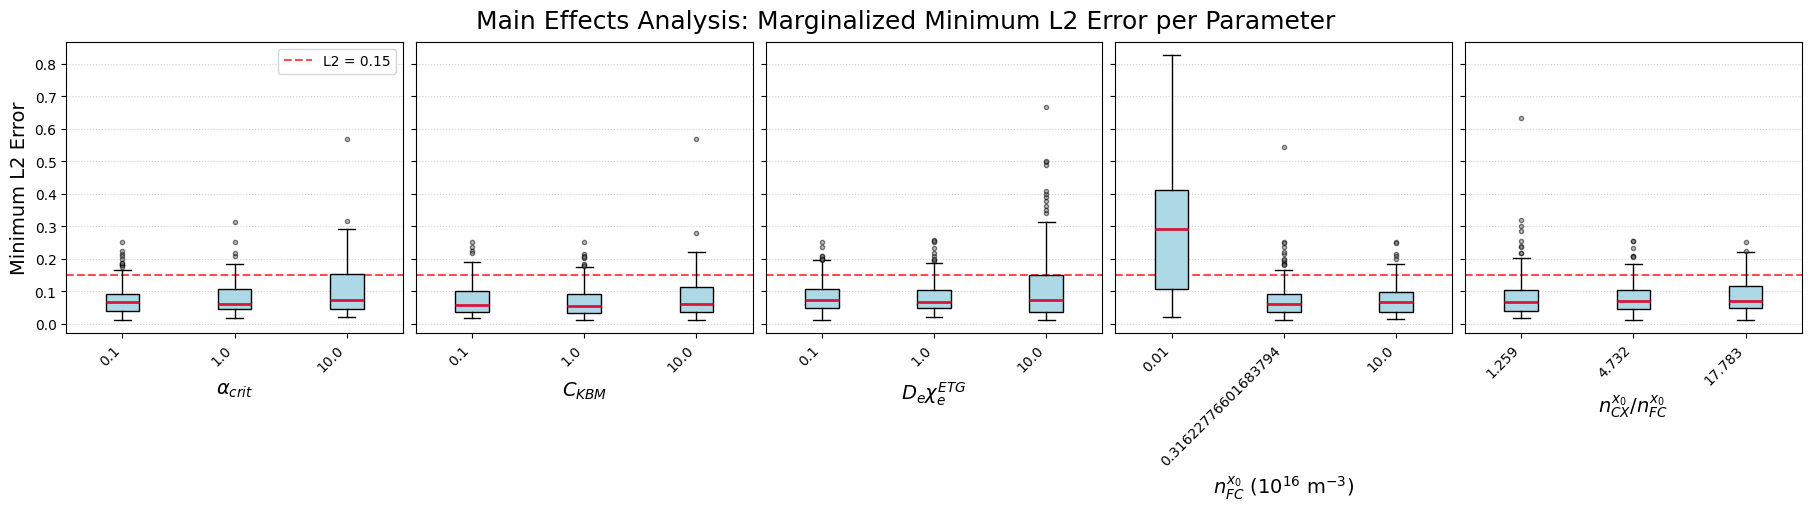

In [18]:
# Option 3
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# --- 1. User Defined Settings & Filepaths ---
L2_THRESHOLD = 0.15

# We scale nf by 1e16 to keep axis labels clean
param_names = [
    r"$\alpha_{crit}$",
    r"$C_{KBM}$",
    r"$D_e\chi_e^{ETG}$",
    r"$n_{FC}^{x_0}$ ($10^{16}$ m$^{-3}$)", 
    r"$n_{CX}^{x_0}/n_{FC}^{x_0}$"
]

success_fp = Path('success_PTHmode.txt')
failure_fp = Path('failure_PTHmode.txt')
error_messages_fp = Path('error_messages_PTHmode.txt')

# --- 2. Data Collection & Marginalization ---
all_runs = []
unique_params = [set() for _ in range(5)]

# Dummy data fallback for demo purposes
try:
    _ = equilibria
    _ = scan_success_dir
except NameError:
    print("Warning: Input data paths not defined. Using dummy data for plotting demo.")
    equilibria = [(f"eq{i}.mhd", f"eq{i}.kprof") for i in range(100)]
    import tempfile
    scan_success_dir = Path(tempfile.gettempdir()) / "pedestal_scan"
    for mhd_fp, _ in equilibria:
        eq_dir = scan_success_dir / mhd_fp[1:]
        eq_dir.mkdir(parents=True, exist_ok=True)
        with open(eq_dir / success_fp, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["tag", "ac", "ck", "de", "nf", "nc", "psi_b", "l2_err"])
            # Generate realistic-looking dummy data
            for _ in range(50):
                ac = np.random.choice([0.1, 1.0, 3.16, 10.0, 31.6])
                ck = np.random.choice([0.1, 0.316, 1.0, 3.16, 10.0])
                nf = np.random.choice([1e14, 5.6e14, 3.2e15, 1.8e16, 1e17])
                # Make low nf artificially worse to mimic real physics behavior
                l2 = np.random.uniform(0.05, 0.25) if nf > 1e15 else np.random.uniform(0.15, 0.6)
                writer.writerow(["tag", ac, ck, 1.0, nf, 1.0, 0.9, l2])

# Parse the actual data
for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    
    if not success_path.exists():
        continue
        
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader) # skip header
        for row in reader:
            if len(row) < 8: continue
            
            try:
                _, ac, ck, de, nf, nc, psi_b, l2_err = [x.strip() for x in row[:8]]
                
                ac, ck, de, nf, nc = round(float(ac), 3), round(float(ck), 3), round(float(de), 3), float(nf), float(nc)
                l2_err = float(l2_err)
                
                # Scale nf for cleaner plotting
                nf_scaled = nf / 1e16
                vals = [ac, ck, de, nf_scaled, nc]
                
            except ValueError:
                continue
                
            all_runs.append((eq_tag, vals, l2_err))
            
            for i in range(5):
                unique_params[i].add(vals[i])

param_grids = [sorted(list(u)) for u in unique_params]

# Initialize marginalized error tracking
# marginalized_errors[param_idx][param_val][eq_tag] = min_l2_err
marginalized_errors = [defaultdict(lambda: defaultdict(lambda: float('inf'))) for _ in range(5)]

for eq_tag, vals, l2_err in all_runs:
    for i in range(5):
        val = vals[i]
        # Update the minimum L2 error for this specific parameter value and equilibrium
        if l2_err < marginalized_errors[i][val][eq_tag]:
            marginalized_errors[i][val][eq_tag] = l2_err

# --- 3. Plotting the Marginalized Boxplots ---
# Use sharey=True so all parameters are visually comparable on the same vertical scale
fig, axes = plt.subplots(1, 5, figsize=(18, 5), constrained_layout=True, sharey=True)

def get_label(val):
    if val < 0.001 or val > 1000:
        return f"{val:.1e}"
    return str(val)

for i in range(5):
    ax = axes[i]
    grid_vals = param_grids[i]
    
    # Extract the distribution of minimum errors for each value in the grid
    plot_data = []
    for val in grid_vals:
        # Get all the best errors achieved by the ensemble for this specific param value
        errors = list(marginalized_errors[i][val].values())
        plot_data.append(errors if errors else [np.nan]) # Handle empty sets safely
        
    # Create the boxplot
    boxprops = dict(facecolor='lightblue', color='black')
    medianprops = dict(color='crimson', linewidth=2)
    flierprops = dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5)
    
    ax.boxplot(plot_data, patch_artist=True, boxprops=boxprops, 
               medianprops=medianprops, flierprops=flierprops)
    
    # Add L2 Threshold reference line
    ax.axhline(L2_THRESHOLD, color='red', linestyle='--', alpha=0.7, zorder=0, label=f"L2 = {L2_THRESHOLD}")
    
    # Formatting
    ax.set_xticks(range(1, len(grid_vals) + 1))
    ax.set_xticklabels([get_label(v) for v in grid_vals], rotation=45, ha='right')
    ax.set_xlabel(param_names[i], fontsize=14)
    
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        ax.set_ylabel("Minimum L2 Error", fontsize=14)
        ax.legend(loc="upper right")

plt.suptitle("Main Effects Analysis: Marginalized Minimum L2 Error per Parameter", fontsize=18)
plt.savefig("marginalized_boxplots.png", dpi=300)
print("Saved plot to marginalized_boxplots.png")
plt.show()